In [2]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [ ]:
!pip install SimpleITK

In [4]:
import glob
#import SimpleITK as sitk
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import random
from scipy import stats

In [11]:
import os
import nibabel as nib

In [7]:
data_path = '/content/gdrive/MyDrive/code/523/data'
os.path.isdir(data_path)

True

In [13]:
groundtruth = nib.load(os.path.join(data_path, "fieldmap_rads_groundtruth.nii")).get_fdata()
mask = nib.load(os.path.join(data_path, "mask.nii")).get_fdata()
snr20 = nib.load(os.path.join(data_path, "t2_snr20_b0space.nii")).get_fdata()
snr40 = nib.load(os.path.join(data_path, "t2_snr40_b0space.nii")).get_fdata()
snrinfinite_ = nib.load(os.path.join(data_path, "t2_snrinfinite_b0space.nii")).get_fdata()

In [25]:
snr20.shape

(180, 212, 136)

In [23]:
def dctMatrixInit(block):
    T = np.zeros((block, block))
    T[0] = np.ones((1, block)) / (block ** 0.5)
    for i in range(1, block):
        for j in range(block):
            T[i][j] = (1 / 2) * np.cos((2 * j + 1) * i * np.pi / 16)
    return T

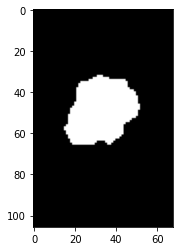

In [120]:
img_mask = mask[15]
plt.imshow(img_mask,cmap='gray')

In [118]:
mask.shape

(90, 106, 68)

In [122]:
img_mask = mask
plt.imshow(img_mask,cmap='gray')

ValueError: ignored

In [119]:
snr20.shape

(180, 212, 136)

In [91]:
img_test = snr20[30]
img_test.shape

(212, 136)

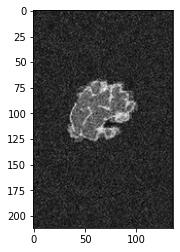

In [82]:
plt.imshow(img_test,cmap='gray')

In [270]:
block = 8
T = dctMatrixInit(block)
# Quantization matrix with discarded last 3 elements
Q = np.zeros((block, block))
a = 5
Q[0:a, 0:a] = np.ones((a, a))

img = img_test
height, width = img.shape

# Ensure Image can be split in blocks by 4 and split it
height = height - height % block
width = width - width % block
hmax = height // block
wmax = width // block

CompIMG = np.zeros((height, width))

MM = img
CC = np.zeros((height, width))
a1=np.array([0.]*2)
a2=np.array([0.]*8)

for i in range(hmax):
  for j in range(wmax):
    # Split into 4x4 blocks
    M = MM[block * i: block * (i + 1), block * j: block * (j + 1)]
    # Execute DCT
    D = np.matmul(np.matmul(T, M), T.T)
    C = D.copy()
    C[0,6:8]=a1
    C[1,6:8]=a1
    C[2,6:8]=a1
    C[3,6:8]=a1
    C[4,6:8]=a1
    C[5,:]=a2
    C[6,:]=a2
    C[7,:]=a2
    #temp[0,0]=C[0,0]
    #temp[0,0]=C[0,0]
    #temp[0,1]=C[0,1]
    #temp[1,0]=C[1,0]
    #temp[1,1]=C[1,1]
    # Build blocks together
    CC[block * i: block * (i + 1), block * j: block * (j + 1)] = C.copy()
for i in range(hmax):
  for j in range(wmax):
    # Inverse DCT T'*CC*T
    CompIMG[block * i: block * (i + 1), block * j: block * (j + 1)] = np.matmul(np.matmul(T.T, CC[block * i: block * (i + 1), block * j: block * (j + 1)]), T)  

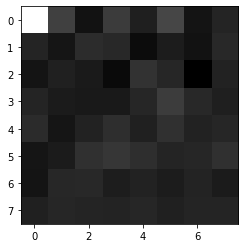

In [256]:
plt.imshow(D,cmap='gray')


In [265]:
D

array([[ 1.60571157e+01,  2.12598436e+00, -1.26186685e+00,
         1.75035006e+00, -3.10027458e-01,  2.55321415e+00,
        -1.11218198e+00,  6.23352075e-02],
       [ 1.30524673e-01, -1.03931081e+00,  7.38372438e-01,
         3.81182943e-01, -1.69465822e+00, -4.91185571e-01,
        -1.26135567e+00,  3.52373275e-01],
       [-1.10387272e+00, -2.33484714e-01, -6.82362163e-01,
        -1.82873609e+00,  1.07304902e+00,  2.09983471e-01,
        -2.59466256e+00, -6.29152751e-02],
       [ 1.11004770e-01, -6.20318418e-01, -7.49328663e-01,
        -7.47092932e-01,  2.36755267e-01,  1.80258738e+00,
         4.01067400e-01, -3.32070460e-01],
       [ 5.75243600e-01, -9.98348949e-01, -7.96986640e-02,
         7.60087696e-01, -1.21517591e-01,  9.43880318e-01,
        -6.14386634e-02,  2.38215501e-01],
       [-1.03891541e+00, -5.88853271e-01,  9.44219954e-01,
         1.35373765e+00,  8.21241082e-01,  7.83805002e-02,
         1.98638146e-01,  1.03973915e+00],
       [-1.08848686e+00,  2.627492

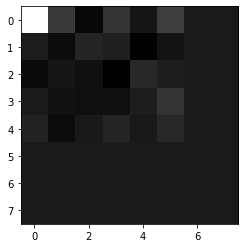

In [271]:
plt.imshow(C,cmap='gray')


In [267]:
print(C)

[[16.05711573  2.12598436 -1.26186685  1.75035006 -0.31002746  0.
   0.          0.        ]
 [ 0.13052467 -1.03931081  0.73837244  0.38118294 -1.69465822  0.
   0.          0.        ]
 [-1.10387272 -0.23348471 -0.68236216 -1.82873609  1.07304902  0.
   0.          0.        ]
 [ 0.11100477 -0.62031842 -0.74932866 -0.74709293  0.23675527  0.
   0.          0.        ]
 [ 0.5752436  -0.99834895 -0.07969866  0.7600877  -0.12151759  0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]]


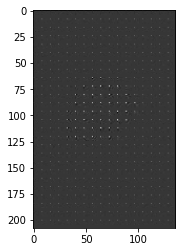

In [272]:
plt.imshow(CC,cmap='gray')

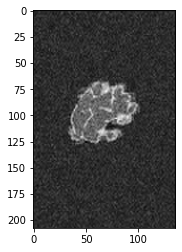

In [273]:
plt.imshow(CompIMG,cmap='gray')

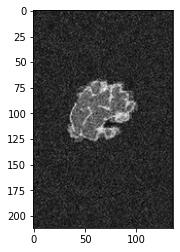

In [274]:
plt.imshow(img_test,cmap='gray')

In [48]:
from PIL import Image
from skimage.util import random_noise

In [66]:
img = Image.open(os.path.join(data_path, "city.jpg"))
width, height = img.size

In [51]:
# Convert rgb to ycbcr
def rgb2ycbcr(im):
    xform = np.array([[.299, .587, .114], [-.1687, -.3313, .5], [.5, -.4187, -.0813]])
    ycbcr = im.dot(xform.T)
    ycbcr[:, :, [1, 2]] += 128
    return np.uint8(ycbcr)


In [67]:
img = rgb2ycbcr(np.array(img))

In [68]:
img.shape

(1080, 1920, 3)

In [69]:
img = random_noise(img, mode='s&p', amount=0.1)
img = np.array(255 * img, dtype='uint8')
img.shape

(1080, 1920, 3)

In [70]:
I = img[:height, :width]

In [71]:
MM = np.array(I, dtype=np.float32)

In [72]:
MM.shape

(1080, 1920, 3)